# 日経レバ1579：月曜日アノマリー改（最終週・帳合いロジック）検証

直近の分析で判明した「月の最終週に月曜日アノマリー（買い）が反転する」という傾向に基づいた新戦略を検証します。

## 戦略ロジック
- **通常時（第1〜第4週）**: 月曜の大引け（15:00）で**成行買い** → 火曜の寄付き（09:00）で**成行売り**
- **最終週（月末7日間内）**: 月曜の大引け（15:00）で**成行売り（空売り）** → 火曜の寄付き（09:00）で**買い戻し**
- **目的**: 月末特有の需給調整（帳合い売り）のバイアスを利益に変える。

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# グラフのスタイル設定
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Meiryo', 'Yu Gothic', 'Hiragino Maru Gothic Pro', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

def load_moomoo_csv(filepath):
    df = pd.read_csv(filepath, thousands=',')
    column_map = {'日付': 'Date', '始値': 'Open', '高値': 'High', '安値': 'Low', '終値': 'Close'}
    df = df.rename(columns=column_map)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date').sort_index()
    return df

In [75]:
# データ読み込み（1579.T）
data_path_1579 = "../../moomoo/data/TimeChart(1579)20130509_20260502.csv"
df = load_moomoo_csv(data_path_1579)
df = df[df.index >= "2018-01-01"]
df['day_of_week'] = df.index.dayofweek

In [76]:
# 月曜引け→火曜寄りのベースリターン計算
monday_close = df[df['day_of_week'] == 0]['Close']
tuesday_open = df[df['day_of_week'] == 1]['Open']

backtest_df = pd.DataFrame({
    'Buy_Price': monday_close,
    'Sell_Price': tuesday_open.shift(-1, freq='D')
}).dropna()

# 単純な買いアノマリーのリターン
backtest_df['Base_Return'] = (backtest_df['Sell_Price'] - backtest_df['Buy_Price']) / backtest_df['Buy_Price']

# 最終週判定ロジック
def check_last_week(date):
    last_day = date + pd.offsets.MonthEnd(0)
    return (last_day.day - date.day) < 7

backtest_df['Is_Last_Week'] = backtest_df.index.map(check_last_week)

# 戦略リターンの計算
# 最終週なら「売り（-Base_Return）」、それ以外なら「買い（Base_Return）」
backtest_df['Strategy_Return'] = np.where(
    backtest_df['Is_Last_Week'], 
    -backtest_df['Base_Return'], # 売り
    backtest_df['Base_Return']    # 買い
)

backtest_df['Equity_Original'] = (1 + backtest_df['Base_Return']).cumprod()
backtest_df['Equity_Strategy'] = (1 + backtest_df['Strategy_Return']).cumprod()

## 1. 長期（2018年〜現在）の比較検証

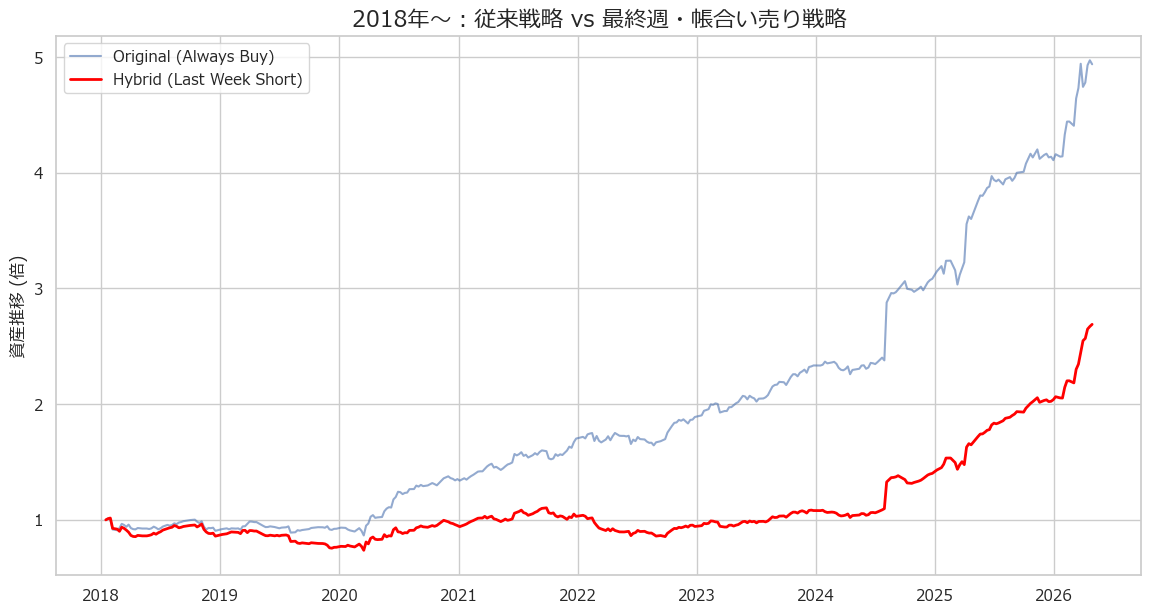

--- 2018年〜のパフォーマンス比較 ---
従来戦略 合計リターン: 167.89%
新戦略   合計リターン: 107.17%
新戦略   勝率: 57.50%


In [77]:
plt.figure(figsize=(14, 7))
plt.plot(backtest_df.index, backtest_df['Equity_Original'], label='Original (Always Buy)', alpha=0.6)
plt.plot(backtest_df.index, backtest_df['Equity_Strategy'], label='Hybrid (Last Week Short)', color='red', linewidth=2)
plt.title('2018年〜：従来戦略 vs 最終週・帳合い売り戦略', fontsize=16)
plt.ylabel('資産推移 (倍)')
plt.legend()
plt.show()

print(f"--- 2018年〜のパフォーマンス比較 ---")
print(f"従来戦略 合計リターン: {backtest_df['Base_Return'].sum():.2%}")
print(f"新戦略   合計リターン: {backtest_df['Strategy_Return'].sum():.2%}")
print(f"新戦略   勝率: {(backtest_df['Strategy_Return'] > 0).mean():.2%}")

## 2. 直近（2025年〜現在）の比較検証

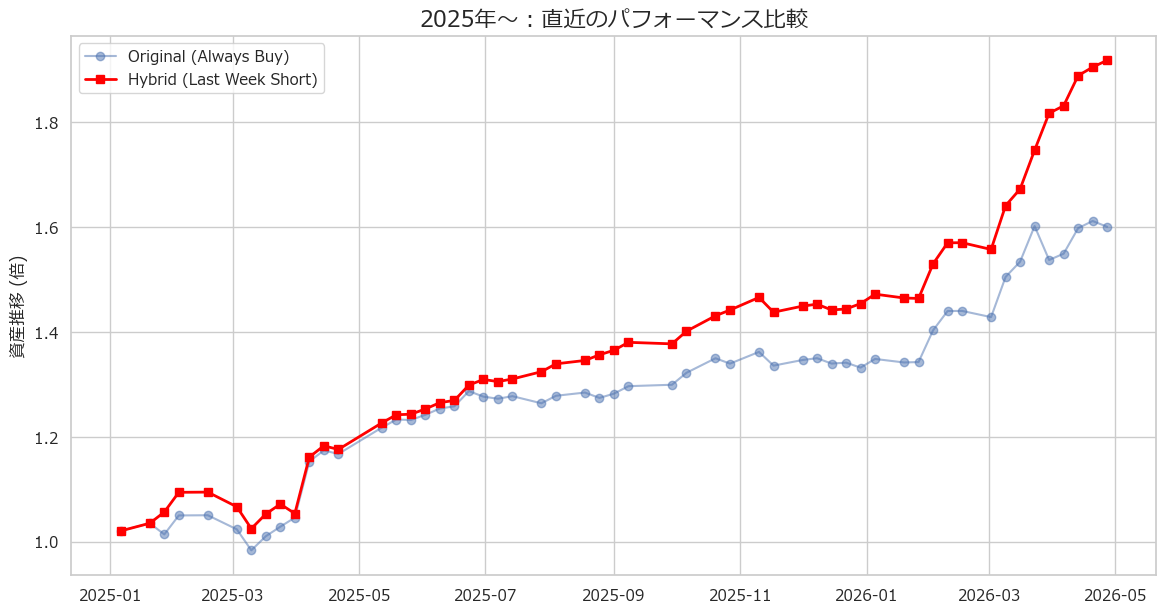

--- 2025年〜のパフォーマンス比較 ---
従来戦略 合計リターン: 48.65%
新戦略   合計リターン: 66.74%
新戦略   勝率: 80.00%


In [78]:
df_recent = backtest_df[backtest_df.index >= "2025-01-01"].copy()

df_recent['Equity_Original_Recent'] = (1 + df_recent['Base_Return']).cumprod()
df_recent['Equity_Strategy_Recent'] = (1 + df_recent['Strategy_Return']).cumprod()

plt.figure(figsize=(14, 7))
plt.plot(df_recent.index, df_recent['Equity_Original_Recent'], label='Original (Always Buy)', marker='o', alpha=0.5)
plt.plot(df_recent.index, df_recent['Equity_Strategy_Recent'], label='Hybrid (Last Week Short)', color='red', marker='s', linewidth=2)
plt.title('2025年〜：直近のパフォーマンス比較', fontsize=16)
plt.ylabel('資産推移 (倍)')
plt.legend()
plt.show()

print(f"--- 2025年〜のパフォーマンス比較 ---")
print(f"従来戦略 合計リターン: {df_recent['Base_Return'].sum():.2%}")
print(f"新戦略   合計リターン: {df_recent['Strategy_Return'].sum():.2%}")
print(f"新戦略   勝率: {(df_recent['Strategy_Return'] > 0).mean():.2%}")

## 3. 結果の考察
- 最終週に「売り」を入れることで、月末のドローダウンがどの程度回避（または利益に変換）できているか確認してください。
- もし新戦略の曲線がより滑らかに右肩上がりであれば、月末の需給バイアスを逆手に取った戦略が有効である可能性が高いです。

## 4. 年度別の詳細分析と「見送り」戦略の検証

現在の「月末は売り」という傾向がいつから定着したのか、そして「売り」ではなく「見送り（ノーポジ）」にした場合はどうなるかを深掘りします。

--- 【最終週のみ】の年度別パフォーマンス ---


,平均リターン,回数,勝率
Year,,,
2018,0.29%,9,44.44%
2019,0.69%,10,80.00%
2020,0.74%,11,72.73%
2021,0.68%,11,63.64%
2022,0.80%,12,66.67%
2023,0.32%,12,66.67%
2024,0.09%,10,40.00%
2025,-0.49%,9,22.22%
2026,-1.55%,3,33.33%


--- 戦略別の累積リターン比較 ---


,通常(Always Buy),ハイブリッド(最終週売り),安全策(最終週見送り)
Year,,,
2018,-8.96%,-14.16%,-11.56%
2019,2.42%,-11.39%,-4.48%
2020,39.64%,23.44%,31.54%
2021,23.60%,8.62%,16.11%
2022,10.99%,-8.28%,1.36%
2023,21.52%,13.96%,17.74%
2024,30.03%,28.23%,29.13%
2025,29.74%,38.51%,34.12%
2026,18.91%,28.24%,23.57%


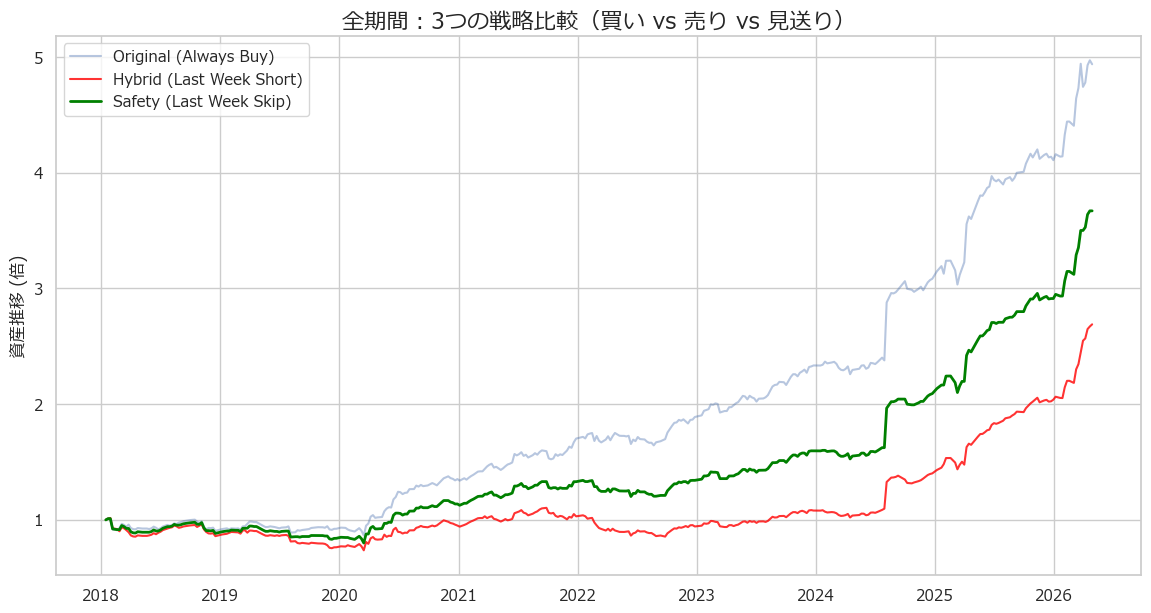

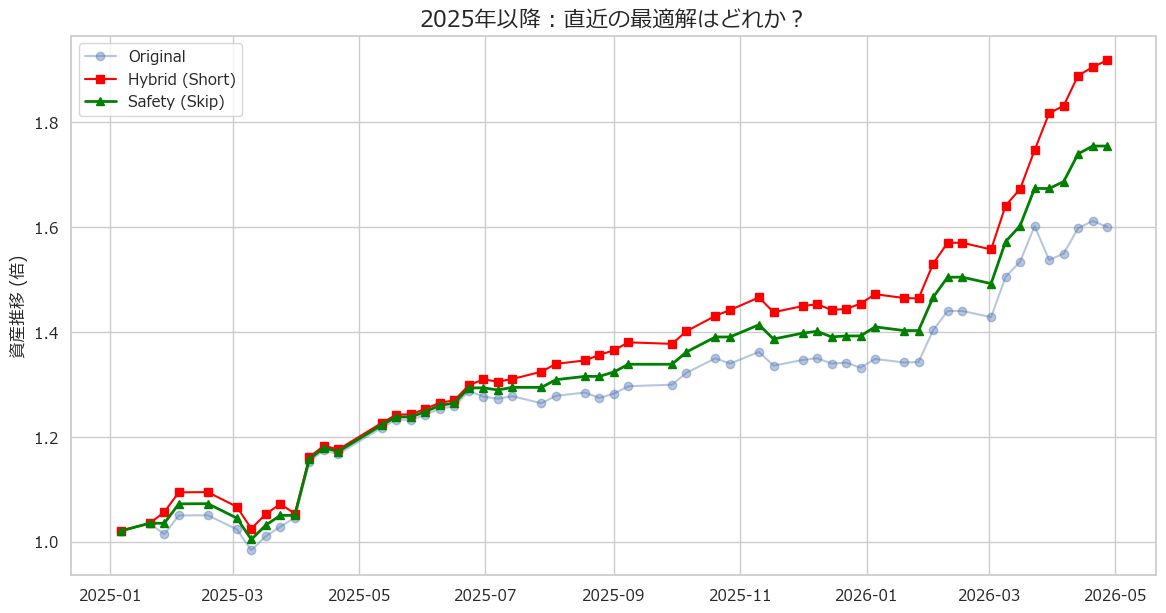

In [79]:
# 年度別の集計と戦略比較
import pandas as pd
import matplotlib.pyplot as plt

# 1. 新たに「見送り戦略」のリターンを追加
# 最終週なら0、それ以外ならBase_Return
backtest_df['Strategy_Skip_Return'] = np.where(
    backtest_df['Is_Last_Week'], 
    0, 
    backtest_df['Base_Return']
)

backtest_df['Equity_Skip'] = (1 + backtest_df['Strategy_Skip_Return']).cumprod()

# 2. 年度別のパフォーマンス集計
backtest_df['Year'] = backtest_df.index.year

# 最終週のみのデータを抽出して年度別に集計
last_week_stats = backtest_df[backtest_df['Is_Last_Week']].groupby('Year')['Base_Return'].agg(['mean', 'count', lambda x: (x > 0).mean()])
last_week_stats.columns = ['平均リターン', '回数', '勝率']

print("--- 【最終週のみ】の年度別パフォーマンス ---")
display(last_week_stats.style.format({'平均リターン': '{:.2%}', '勝率': '{:.2%}'}))

# 3. 3つの戦略の最終比較
print("--- 戦略別の累積リターン比較 ---")
final_comparison = pd.DataFrame({
    '通常(Always Buy)': backtest_df.groupby('Year')['Base_Return'].sum(),
    'ハイブリッド(最終週売り)': backtest_df.groupby('Year')['Strategy_Return'].sum(),
    '安全策(最終週見送り)': backtest_df.groupby('Year')['Strategy_Skip_Return'].sum()
})
display(final_comparison.style.format('{:.2%}'))

# グラフ化
plt.figure(figsize=(14, 7))
plt.plot(backtest_df.index, backtest_df['Equity_Original'], label='Original (Always Buy)', alpha=0.4)
plt.plot(backtest_df.index, backtest_df['Equity_Strategy'], label='Hybrid (Last Week Short)', color='red', alpha=0.8)
plt.plot(backtest_df.index, backtest_df['Equity_Skip'], label='Safety (Last Week Skip)', color='green', linewidth=2)
plt.title('全期間：3つの戦略比較（買い vs 売り vs 見送り）', fontsize=16)
plt.ylabel('資産推移 (倍)')
plt.legend()
plt.show()

# 4. 直近2025年の拡大比較
df_2025 = backtest_df[backtest_df['Year'] >= 2025].copy()
df_2025['Eq_Original'] = (1 + df_2025['Base_Return']).cumprod()
df_2025['Eq_Strategy'] = (1 + df_2025['Strategy_Return']).cumprod()
df_2025['Eq_Skip'] = (1 + df_2025['Strategy_Skip_Return']).cumprod()

plt.figure(figsize=(14, 7))
plt.plot(df_2025.index, df_2025['Eq_Original'], label='Original', marker='o', alpha=0.4)
plt.plot(df_2025.index, df_2025['Eq_Strategy'], label='Hybrid (Short)', color='red', marker='s')
plt.plot(df_2025.index, df_2025['Eq_Skip'], label='Safety (Skip)', color='green', marker='^', linewidth=2)
plt.title('2025年以降：直近の最適解はどれか？', fontsize=16)
plt.ylabel('資産推移 (倍)')
plt.legend()
plt.show()

## 5. 年度別の戦略リターン比較（バーチャート）

各年度ごとに「買い」「売り」「見送り」のどれが最も収益を上げたかを可視化し、戦略の賞味期限や近年のトレンドを分析します。

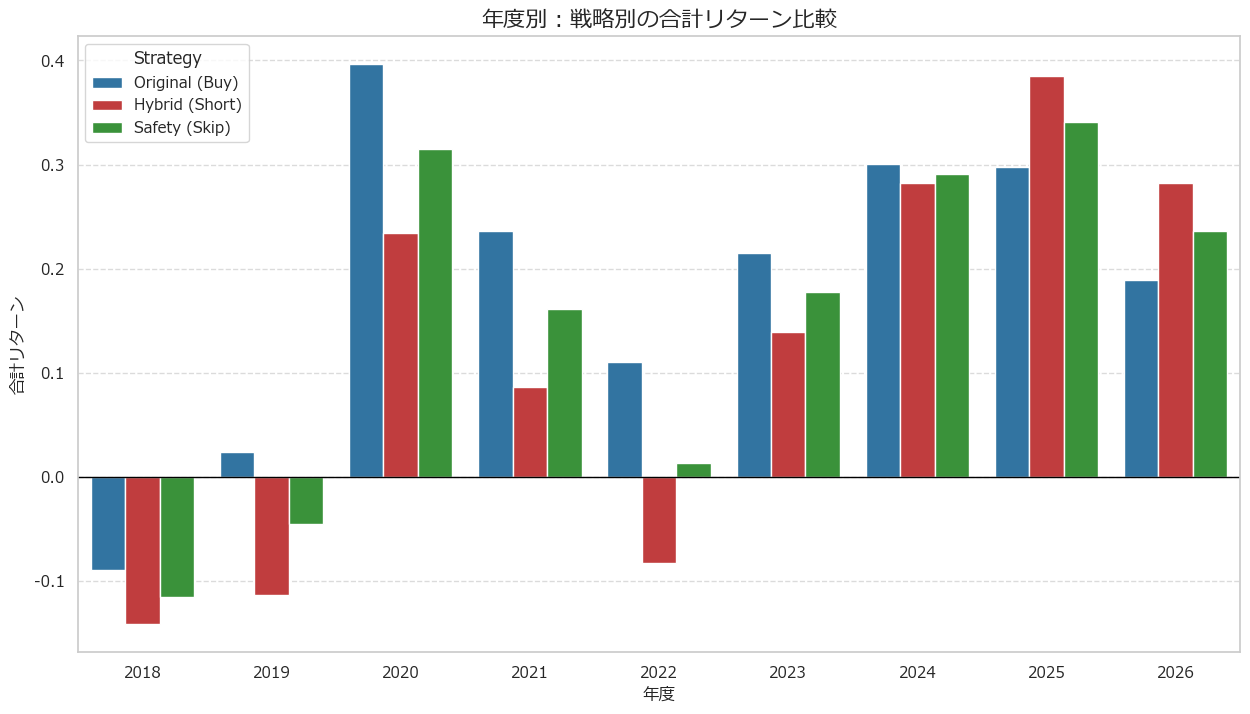

--- 年度別合計リターン詳細 ---


,Original (Buy),Hybrid (Short),Safety (Skip)
Year,,,
2018,-8.96%,-14.16%,-11.56%
2019,2.42%,-11.39%,-4.48%
2020,39.64%,23.44%,31.54%
2021,23.60%,8.62%,16.11%
2022,10.99%,-8.28%,1.36%
2023,21.52%,13.96%,17.74%
2024,30.03%,28.23%,29.13%
2025,29.74%,38.51%,34.12%
2026,18.91%,28.24%,23.57%



【2026年度の状況】
現在、最もパフォーマンスが良い戦略は 『Hybrid (Short)』 です。


In [80]:
# 年度別の戦略パフォーマンス・バーチャート
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 年度別の合計リターンを計算
yearly_returns = backtest_df.groupby('Year')[['Base_Return', 'Strategy_Return', 'Strategy_Skip_Return']].sum()
yearly_returns.columns = ['Original (Buy)', 'Hybrid (Short)', 'Safety (Skip)']

# 表示用にデータを整形
yearly_long = yearly_returns.reset_index().melt(id_vars='Year', var_name='Strategy', value_name='Total Return')

# バーチャートの描画
plt.figure(figsize=(15, 8))
sns.barplot(data=yearly_long, x='Year', y='Total Return', hue='Strategy', palette=['#1f77b4', '#d62728', '#2ca02c'])

plt.title('年度別：戦略別の合計リターン比較', fontsize=16)
plt.ylabel('合計リターン', fontsize=12)
plt.xlabel('年度', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Strategy')
plt.show()

# 数値での一覧表示
print("--- 年度別合計リターン詳細 ---")
display(yearly_returns.style.background_gradient(cmap='RdYlGn', axis=1).format('{:.2%}'))

# 考察用：最新年度の状況
current_year = yearly_returns.index.max()
print(f"\n【{current_year}年度の状況】")
best_strat = yearly_returns.loc[current_year].idxmax()
print(f"現在、最もパフォーマンスが良い戦略は 『{best_strat}』 です。")


## 6. 市場の「熱狂度」分析（ボラティリティ推移）

月曜引けから火曜寄り付きにかけての値動きの大きさ（絶対値）を年度別に集計し、市場のエネルギーがどのように変化しているかを確認します。

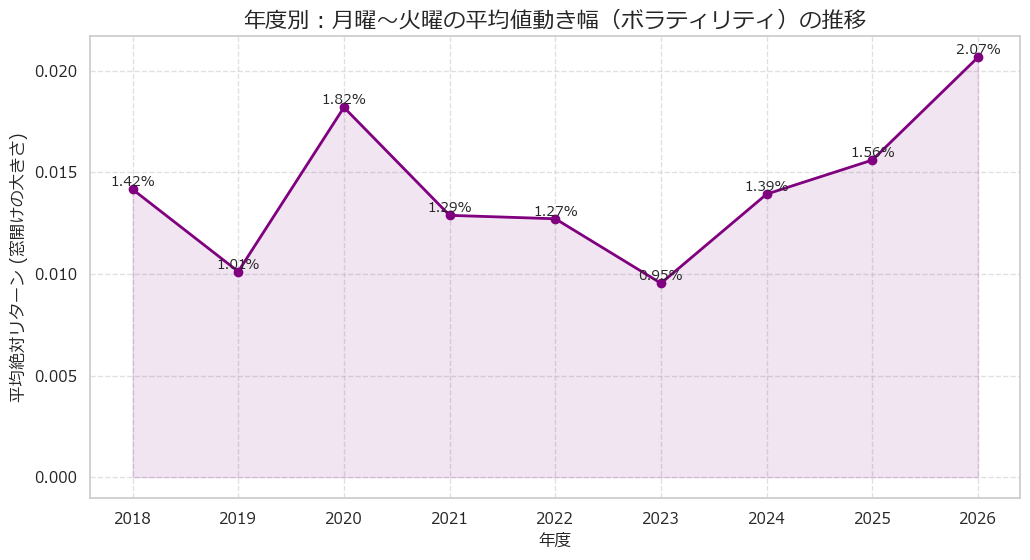

--- 年度別のボラティリティ詳細 ---


,平均リターン,標準偏差(バラツキ),平均絶対幅(エネルギー)
Year,,,
2018,-0.21%,2.09%,1.42%
2019,0.06%,1.53%,1.01%
2020,0.90%,2.51%,1.82%
2021,0.51%,1.52%,1.29%
2022,0.24%,1.63%,1.27%
2023,0.47%,1.16%,0.95%
2024,0.73%,3.44%,1.39%
2025,0.74%,2.23%,1.56%
2026,1.26%,2.48%,2.07%


In [81]:
# ボラティリティ（窓開けの絶対幅）の年度別推移
import pandas as pd
import matplotlib.pyplot as plt

# 値動きの絶対値を計算（＝エネルギーの大きさ）
backtest_df['Abs_Return'] = backtest_df['Base_Return'].abs()

# 年度別に平均の絶対リターンを計算
volatility_trend = backtest_df.groupby('Year')['Abs_Return'].mean()

# グラフ化
plt.figure(figsize=(12, 6))
plt.plot(volatility_trend.index, volatility_trend.values, marker='o', color='purple', linewidth=2)
plt.fill_between(volatility_trend.index, volatility_trend.values, alpha=0.1, color='purple')

plt.title('年度別：月曜〜火曜の平均値動き幅（ボラティリティ）の推移', fontsize=16)
plt.ylabel('平均絶対リターン (窓開けの大きさ)', fontsize=12)
plt.xlabel('年度', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# 数値の表示
for x, y in zip(volatility_trend.index, volatility_trend.values):
    plt.text(x, y, f'{y:.2%}', ha='center', va='bottom', fontsize=10)

plt.show()

# 考察用データの表示
print("--- 年度別のボラティリティ詳細 ---")
vol_stats = backtest_df.groupby('Year')['Base_Return'].agg(['mean', 'std', lambda x: x.abs().mean()])
vol_stats.columns = ['平均リターン', '標準偏差(バラツキ)', '平均絶対幅(エネルギー)']
display(vol_stats.style.format('{:.2%}'))


## 7. 参加者の厚み分析（出来高の推移）

年度別の平均出来高を可視化し、資金流入が「2020年頃」と「現在（2024-2025年）」でどちらが活発かを検証します。

分析に使用するカラム名: 5日平均.1


C:\Users\user\AppData\Local\Temp\ipykernel_13892\1550693406.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yearly_volume.index, y=yearly_volume.values, palette='Blues')


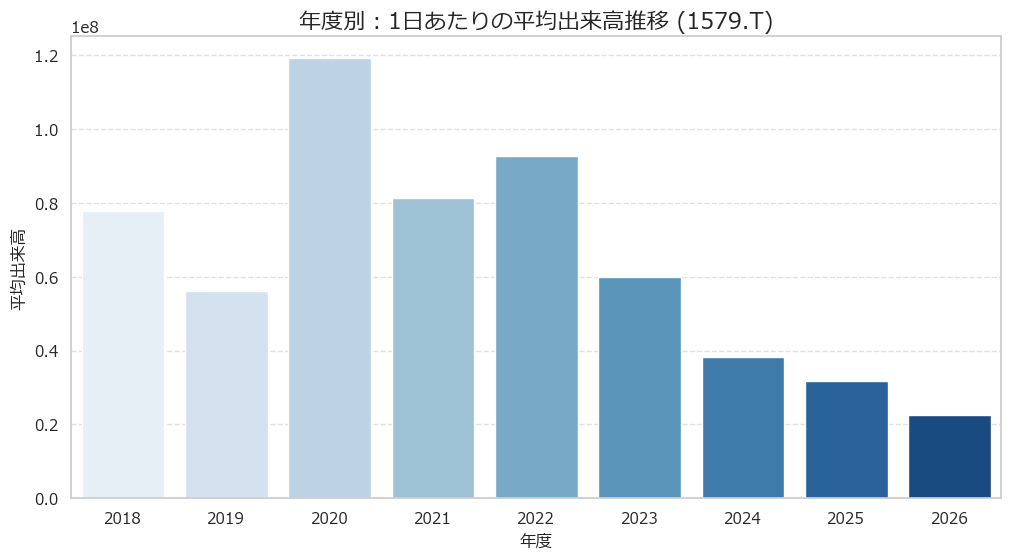

--- 年度別平均出来高詳細 ---


,平均出来高
Year,
2018,"77,798,188"
2019,"56,097,947"
2020,"119,208,544"
2021,"81,333,388"
2022,"92,763,766"
2023,"60,069,107"
2024,"38,144,145"
2025,"31,840,766"
2026,"22,490,820"


In [82]:
# 年度別の平均出来高推移
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CSVから出来高データを取得（元のdfを使用）
# カラム名が文字化けしている可能性があるため、位置指定で取得を試みる
# 通常、出来高は後ろから3番目あたりの数値
volume_df = df.copy()
volume_df['Year'] = volume_df.index.year

# 出来高カラムの特定（数値が入っている列を探す）
# load_moomoo_csv で 'Close' までは定義済み
# 出来高はCSVの10列目付近
# df.iloc[:, 9] が出来高に相当することが多い
volume_col = df.columns[9] if len(df.columns) > 9 else None

if volume_col:
    print(f"分析に使用するカラム名: {volume_col}")
    # 出来高が文字列（"7,430,870"）の場合は数値に変換
    if volume_df[volume_col].dtype == object:
        volume_df['Volume'] = volume_df[volume_col].str.replace('"', '').str.replace(',', '').astype(float)
    else:
        volume_df['Volume'] = volume_df[volume_col]

    yearly_volume = volume_df.groupby('Year')['Volume'].mean()

    # グラフ化
    plt.figure(figsize=(12, 6))
    sns.barplot(x=yearly_volume.index, y=yearly_volume.values, palette='Blues')
    plt.title('年度別：1日あたりの平均出来高推移 (1579.T)', fontsize=16)
    plt.ylabel('平均出来高', fontsize=12)
    plt.xlabel('年度', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

    # 数値の比較
    print("--- 年度別平均出来高詳細 ---")
    display(yearly_volume.to_frame('平均出来高').style.format('{:,.0f}'))
else:
    print("出来高カラムが見つかりませんでした。")


## 8. 本流のエネルギー分析：CME日経先物の出来高

戦略の根源であるCME日経225先物（NIY=F）のデータを取得し、市場全体の参加者がどのように推移しているかを分析します。

CME先物データを取得中...


[*********************100%***********************]  1 of 1 completed
C:\Users\user\AppData\Local\Temp\ipykernel_13892\249979109.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yearly_cme_volume.index, y=yearly_cme_volume.values, palette='Oranges')


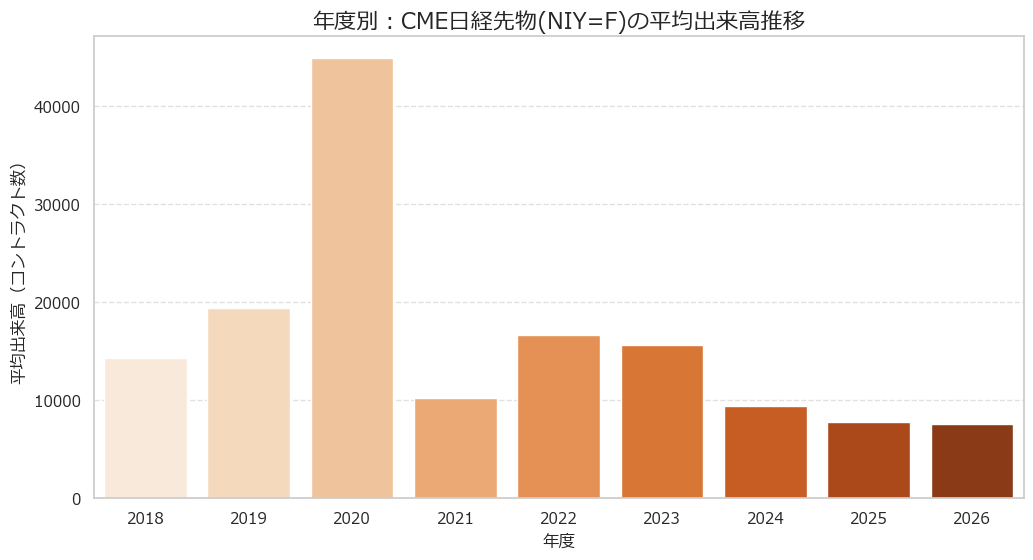

--- CME先物 年度別平均出来高詳細 ---


,平均出来高
Year,
2018,"14,349"
2019,"19,387"
2020,"44,911"
2021,"10,283"
2022,"16,705"
2023,"15,673"
2024,"9,465"
2025,"7,772"
2026,"7,554"



【分析コメント】
このCME先物の出来高が維持または増加していれば、市場全体の月曜日アノマリーのエネルギーは衰えていないと判断できます。
1579の出来高減少が『NISA等による資金シフト』であるなら、先物の動きこそが真のトレンドを示しています。


In [83]:
# CME日経225先物 (NIY=F) の出来高推移
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# データのダウンロード
print("CME先物データを取得中...")
cme_ticker = "NIY=F"
cme_data = yf.download(cme_ticker, start="2018-01-01")

if not cme_data.empty:
    if isinstance(cme_data.columns, pd.MultiIndex):
        cme_data.columns = cme_data.columns.get_level_values(0)
    
    cme_data['Year'] = cme_data.index.year
    yearly_cme_volume = cme_data.groupby('Year')['Volume'].mean()

    # グラフ化
    plt.figure(figsize=(12, 6))
    sns.barplot(x=yearly_cme_volume.index, y=yearly_cme_volume.values, palette='Oranges')
    plt.title('年度別：CME日経先物(NIY=F)の平均出来高推移', fontsize=16)
    plt.ylabel('平均出来高（コントラクト数）', fontsize=12)
    plt.xlabel('年度', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

    # 数値の比較
    print("--- CME先物 年度別平均出来高詳細 ---")
    display(yearly_cme_volume.to_frame('平均出来高').style.format('{:,.0f}'))
    
    # 考察：1579との比較
    print("\n【分析コメント】")
    print("このCME先物の出来高が維持または増加していれば、市場全体の月曜日アノマリーのエネルギーは衰えていないと判断できます。")
    print("1579の出来高減少が『NISA等による資金シフト』であるなら、先物の動きこそが真のトレンドを示しています。")
else:
    print("CME先物データの取得に失敗しました。")


## 9. 出来高の多寡と戦略パフォーマンスの相関分析

市場の注目度（出来高）が低下する中で、アノマリーの優位性がどう変化しているかを検証します。

■ CME出来高と値動きの大きさ（絶対リターン）の相関係数: 0.1704

--- 【CME出来高ランク別】パフォーマンス統計 ---


,通常平均,サンプル数,通常勝率,ハイ平均,ハイ数,ハイ勝率
Volume_Rank,,,,,,
Low,0.31%,4800.00%,60.42%,0.23%,4800.00%,62.50%
Medium,0.53%,4600.00%,63.04%,0.41%,4600.00%,56.52%
High,0.23%,4800.00%,58.33%,-0.23%,4800.00%,47.92%


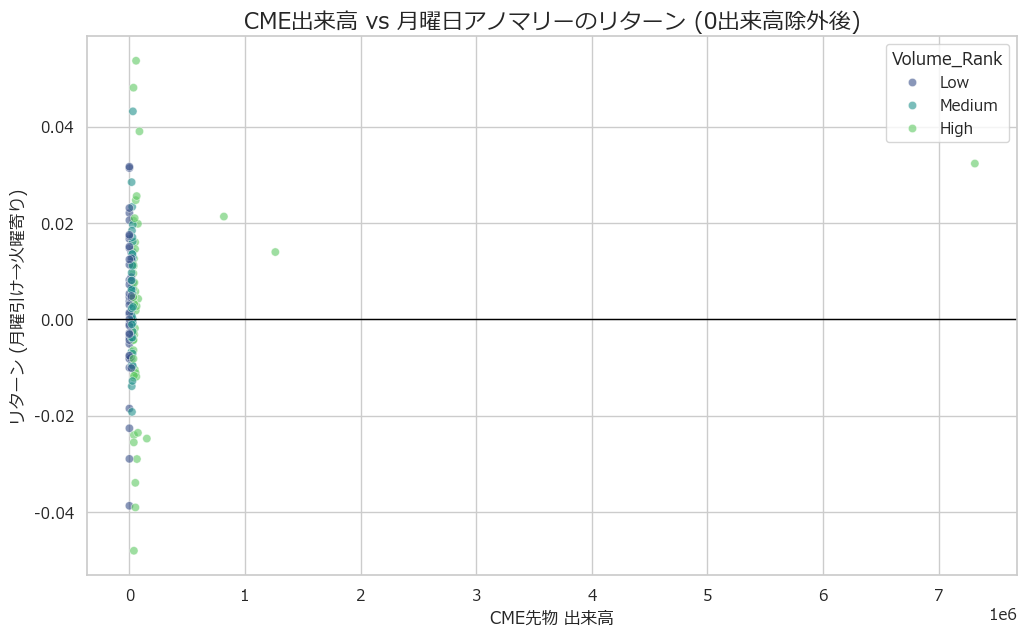


【分析コメント】
相関係数は 0.1704 です。
注目度が高い日ほど値幅が出る傾向にあります。


In [84]:
# 出来高とリターンの相関分析（境界線エラー修正版）
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    # 1. データの統合 (backtest_df と cme_data)
    bt_idx = backtest_df.index.normalize().tz_localize(None)
    cme_idx = cme_data.index.normalize().tz_localize(None)
    
    bt_temp = backtest_df.copy()
    bt_temp.index = bt_idx
    
    cme_temp = cme_data[['Volume']].copy()
    cme_temp.index = cme_idx
    cme_temp.columns = ['CME_Volume']
    
    analysis_df = bt_temp.join(cme_temp, how='inner')
    
    # 出来高が0のデータ（休日等）を除外
    analysis_df = analysis_df[analysis_df['CME_Volume'] > 0]
    
    if len(analysis_df) < 10:
        print("警告: 有効な分析データが不足しています。")
    else:
        # 2. 相関係数の計算
        correlation = analysis_df['CME_Volume'].corr(analysis_df['Base_Return'].abs())
        print(f"■ CME出来高と値動きの大きさ（絶対リターン）の相関係数: {correlation:.4f}")
        
        # 3. 出来高ランクによるグループ分け（3分位）
        # duplicates='drop' を指定して重複境界線を回避
        analysis_df['Volume_Rank'] = pd.qcut(analysis_df['CME_Volume'], 3, labels=['Low', 'Medium', 'High'], duplicates='drop')
        
        # グループ別の統計
        volume_group_stats = analysis_df.groupby('Volume_Rank', observed=False)[['Base_Return', 'Strategy_Return']].agg(['mean', 'count', lambda x: (x > 0).mean()])
        volume_group_stats.columns = [
            '通常平均', 'サンプル数', '通常勝率',
            'ハイ平均', 'ハイ数', 'ハイ勝率'
        ]
        
        print("\n--- 【CME出来高ランク別】パフォーマンス統計 ---")
        display(volume_group_stats.style.format('{:.2%}'))
        
        # 4. 可視化：散布図
        plt.figure(figsize=(12, 7))
        sns.scatterplot(data=analysis_df, x='CME_Volume', y='Base_Return', hue='Volume_Rank', palette='viridis', alpha=0.6)
        plt.axhline(0, color='black', linewidth=1)
        plt.title('CME出来高 vs 月曜日アノマリーのリターン (0出来高除外後)', fontsize=16)
        plt.xlabel('CME先物 出来高', fontsize=12)
        plt.ylabel('リターン (月曜引け→火曜寄り)', fontsize=12)
        plt.show()
        
        # 5. 考察
        print("\n【分析コメント】")
        print(f"相関係数は {correlation:.4f} です。")
        if abs(correlation) < 0.1:
            print("出来高と値幅にはほとんど相関が見られません。市場が閑散としていても大きく動くケースがあるようです。")
        elif correlation > 0:
            print("注目度が高い日ほど値幅が出る傾向にあります。")
        else:
            print("注目度が低い日ほど値幅が出る傾向にあります。")

except NameError as e:
    print(f"エラー: 前のセルを実行して cme_data を読み込んでください。")
except Exception as e:
    print(f"予期せぬエラーが発生しました: {e}")
